In [1]:
# use the same interpreter the notebook is running
import sys; print(sys.executable)

%pip install --upgrade pip
%pip install numpy matplotlib
# (optional) MATLAB engine wheel for R2025a:
%pip install matlabengine==25.1.2


C:\Users\13523\venvs\lab\Scripts\python.exe
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matlab.engine 



In [3]:
#write data to python file

eng = matlab.engine.start_matlab()
eng.eval("load('shared.mat')", nargout=0)   # or run your script to create y_accum
y_accum = np.array(eng.workspace['y_accum'])
Xgrid   = np.array(eng.workspace['Xgrid'])
Ygrid   = np.array(eng.workspace['Ygrid'])
Zgrid   = np.array(eng.workspace['Zgrid'])


In [4]:
#size sanity check
def print_size(name):
    try:
        v = eng.workspace[name]
    except KeyError:
        print(f"{name}: not found")
        return
    sz = tuple(np.array(eng.size(v, nargout=1)).ravel().astype(int))
    print(f"{name}: {sz}")

print_size("y_accum")
print_size("Xgrid")
print_size("Ygrid")
print_size("Zgrid")

y_accum: (np.int64(60), np.int64(60), np.int64(25))
Xgrid: (np.int64(60), np.int64(1), np.int64(60))
Ygrid: (np.int64(60), np.int64(1), np.int64(60))
Zgrid: (np.int64(60), np.int64(1), np.int64(60))


In [5]:
mag = np.abs(y_accum)
eps = 1e-12
N = y_accum.shape[2]                 # number of images
imgs_db = 20*np.log10(mag / (mag.max() + eps) + eps)

ymin, ymax = float(Ygrid.min()), float(Ygrid.max())
zmin, zmax = float(Zgrid.min()), float(Zgrid.max())

vmin, vmax = np.percentile(imgs_db, 5), np.percentile(imgs_db, 99)


In [6]:
for i in range(N):
    img = imgs_db[:, :, i]           # NOT y_accum(:,:,i)
    val = np.nanmin(np.abs(img))     # magnitude; ignores NaNs
    
    print(f"image {i+1} min is {val:.2f}\n")
    print(f"image {i+1} max is {np.nanmax(np.abs(img))}\n")

image 1 min is 21.20

image 1 max is 100.22537231445312

image 2 min is 18.96

image 2 max is 83.6739273071289

image 3 min is 15.11

image 3 max is 84.58465576171875

image 4 min is 4.68

image 4 max is 102.84394073486328

image 5 min is 15.17

image 5 max is 94.02976989746094

image 6 min is 20.25

image 6 max is 92.05224609375

image 7 min is 10.96

image 7 max is 87.06256103515625

image 8 min is 0.00

image 8 max is 82.48297882080078

image 9 min is 12.80

image 9 max is 97.37277221679688

image 10 min is 18.33

image 10 max is 113.72975158691406

image 11 min is 17.30

image 11 max is 93.11843872070312

image 12 min is 1.86

image 12 max is 82.84837341308594

image 13 min is 14.66

image 13 max is 91.18766021728516

image 14 min is 21.82

image 14 max is 85.54087829589844

image 15 min is 25.32

image 15 max is 83.72992706298828

image 16 min is 25.15

image 16 max is 89.52152252197266

image 17 min is 21.32

image 17 max is 93.54048919677734

image 18 min is 19.73

image 18 max 

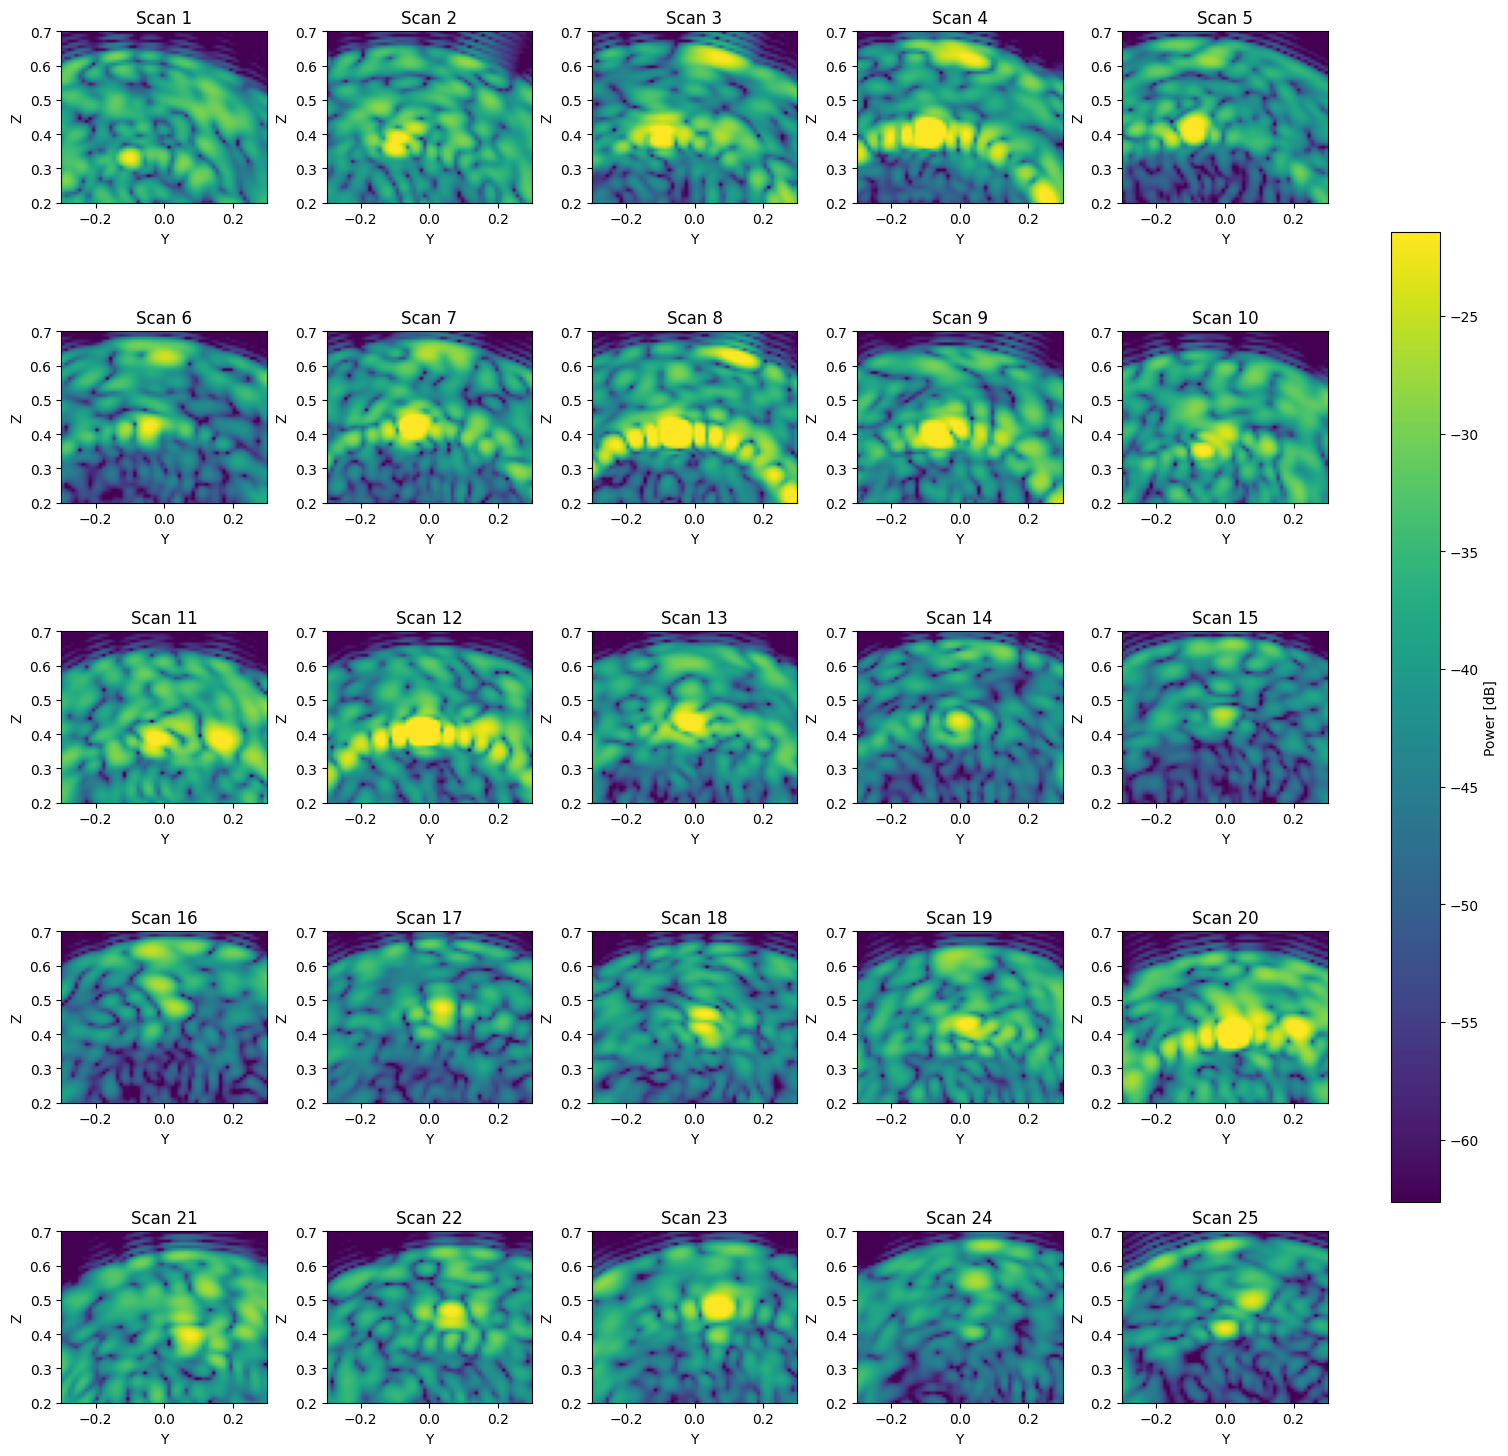

In [7]:
#plotting
fig, axes = plt.subplots(5, 5, figsize=(15, 15), constrained_layout=True)
for i, ax in enumerate(axes.flat):
    im = ax.imshow(imgs_db[:, :, i].T,
                   origin='lower', aspect='equal',
                   extent=[ymin, ymax, zmin, zmax],
                   vmin=vmin, vmax=vmax)
    ax.set_title(f"Scan {i+1}")
    ax.set_xlabel("Y"); ax.set_ylabel("Z")
    #Axes.set_ylim(20,30); Axes.set_xlim(20,30);

fig.colorbar(im, ax=axes, shrink=0.65, label="Power [dB]")
plt.show()

